In [8]:
# this was used to install seaborn for the correlation heatmap, but it is not needed for the final version of the notebook

# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [9]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py



## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


Structure of the h5 file:
highest order groups: ['entry']
elements in entry: ['acquisition', 'meta', 'per_layer']
elements in acquisition: ['data', 'x_axis', 'y_axis', 'z_axis']
Shape of the labels dataframe: (1765, 1)
First few rows of the labels dataframe:
   Resolution
0           3
1           3
2           2
3           2
4           2
Shape of the dataset: (288, 216, 1765)
Number of samples: 1765
Example data:


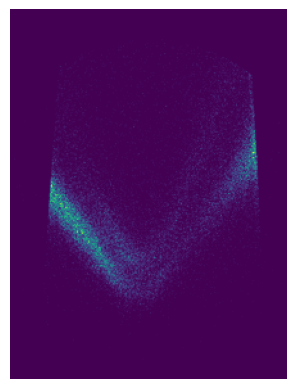

In [10]:
import pandas as pd

# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
#df = pd.read_csv('your_dataset.csv')

# small test file: x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5
# big unbinned file: x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103607.h5

hf = h5py.File('../../ML_data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5', 'r')
print("Structure of the h5 file:")
print(f"highest order groups: {list(hf.keys())}")
general_group = hf.get('entry')
print(f"elements in entry: {list(general_group.keys())}")
#access to all keys of the h5 file to understand its structure and find the relevant dataset for analysis
# the groups meta and per_layer are none type
acquisition_group = general_group.get('acquisition')
print(f"elements in acquisition: {list(acquisition_group.keys())}")
# the key data contains the dataset we are interested in
data_group = acquisition_group.get('data')

#import of the labels from a seperate csv file, as they are not included in the h5 file
#labels_df = pd.read_csv('../../../ML_data/Classification_table.csv', delimiter=';', usecols=['Symmetrie', 'Resolution'])
labels_df = pd.read_excel('../../ML_data/Classification_table_Version3.xlsx', usecols=['Resolution'])
print(f"Shape of the labels dataframe: {labels_df.shape}")
print(f"First few rows of the labels dataframe:\n{labels_df.head()}")

# the dataset is stored as a numpy array
df = data_group[:]
print(f"Shape of the dataset: {df.shape}")

# we did notconvert the numpy array to a pandas dataframe, as there have been some issues with the conversion, 
# and we can work with the numpy array directly for our analysis. 


# Number of samples
num_samples = df.shape[2]

# Number of features: we have only the intensity as a feature
#num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
#print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")

plt.imshow(df[:,:,0])
plt.axis('off')  # Turn off axis labels
plt.show()



## Function to evaluate the overall intensity of one spectrum
This is needed for the detection of missing values, which would be pictures without any intensity. 
Later on we will need this as well for the evaluation of a correlation between the intensity and the labeling. 

In [11]:
def i_sum(df, sample_index):
    return np.sum(df[:,:,sample_index])

# Calculate intensity sum for each sample and add to labels_df
intensity_sums = [i_sum(df, i) for i in range(num_samples)]
labels_df['intensity_sum'] = intensity_sums


## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [12]:
# Check for missing values
missing_values = 0
for i in range(num_samples):
    if i_sum(df, i) == 0:
        missing_values += 1
print(f"Dataset has {missing_values} samples with missing values (sum of intensities is zero).")

Dataset has 0 samples with missing values (sum of intensities is zero).


In [13]:
# Handling missing values
# Example: Replacing NaN values with the mean value of the column
# df.fillna(df.mean(), inplace=True)

# Your code for handling missing values goes here


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


In [14]:
# Example: Plotting histograms of all numerical features
#df.hist(figsize=(12, 12))
#plt.show()

# not relevant for the dataset, since it only contains 3 features (x, y, z) 
# which are not numerical features in the traditional sense, 
# but rather intensity over x and y coordinates of z pictures. 


## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


<Axes: xlabel='Resolution', ylabel='count'>

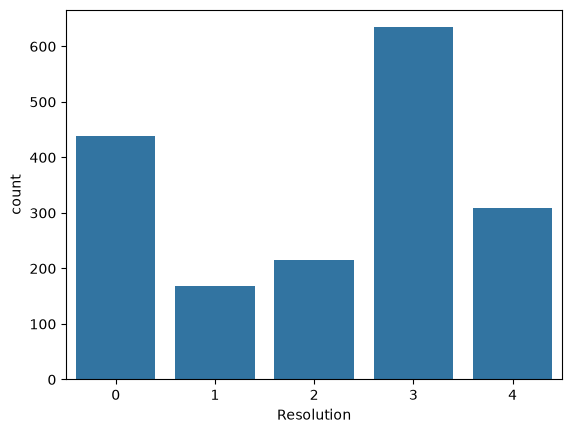

In [15]:
# Example: Checking for class imbalance in a classification problem
sns.countplot(x='Resolution', data=labels_df)

# Your code to investigate possible biases goes here
#


## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


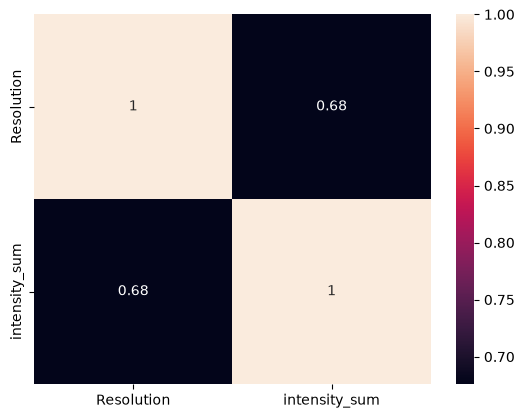

In [16]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = labels_df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()

# In this case, we want to check, wether there is a correlation between 
# the overall intensity of the picture (x,y) and the asigned quality label.


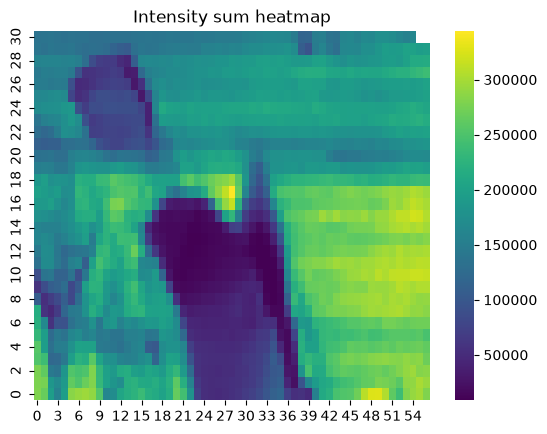

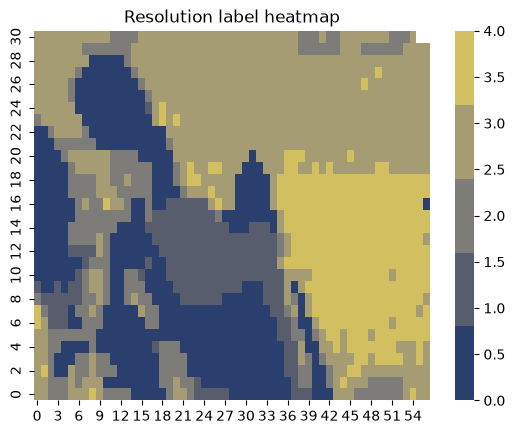

KeyError: 'Symmetrie'

In [17]:
# heatmaps to show the distribution of the intensity sums across the samples as well as the distribution of the quality labels (Resolution and Symmetrie).

from matplotlib.colors import ListedColormap
def i_sum(df, sample_index):
    return np.sum(df[:, :, sample_index])

# Calculate intensity sum for each sample and add to labels_df
intensity_sums = [i_sum(df, i) for i in range(num_samples)]
labels_df['intensity_sum'] = intensity_sums

x = 57 # number of measurements (ARPES spectra) in x direction on sample

# To create a heatmap, we need to reshape the intensity sums into a 2D array
arr = labels_df['intensity_sum'].to_numpy().astype(float)
pad_len = (-len(arr)) % x
arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
intensity_matrix = arr_padded.reshape(-1, x)

ax = sns.heatmap(intensity_matrix, cmap='viridis', cbar=True)
ax.invert_yaxis()
plt.title('Intensity sum heatmap')
plt.show()

# set label heatmap

labels_df['new_label'] = labels_df['Resolution'] 
label_arr = labels_df['new_label'].to_numpy().astype(float)
label_arr_padded = np.pad(label_arr, (0, pad_len), constant_values=np.nan)
label_matrix = label_arr_padded.reshape(-1, x)

label_cmap = ListedColormap(sns.color_palette('cividis', 5))
ax = sns.heatmap(label_matrix, cmap=label_cmap, cbar=True)
ax.invert_yaxis()
plt.title('Resolution label heatmap')
plt.show()

# symmetry heatmap

labels_df['new_label'] = labels_df['Symmetrie'] 
label_arr = labels_df['new_label'].to_numpy().astype(float)
label_arr_padded = np.pad(label_arr, (0, pad_len), constant_values=np.nan)
label_matrix = label_arr_padded.reshape(-1, x)

label_cmap = ListedColormap(sns.color_palette('cividis', 5))
ax = sns.heatmap(label_matrix, cmap=label_cmap, cbar=True)
ax.invert_yaxis()
plt.title('Symmetry label heatmap')
plt.show()

# Create a new label column: if Symmetrie is 0, new_label is 0, otherwise it is the value of Resolution ( 0 to 5 )
labels_df['new_label'] = np.where(labels_df['Symmetrie'] == 0, 0, labels_df['Resolution'])
label_arr = labels_df['new_label'].to_numpy().astype(float)
label_arr_padded = np.pad(label_arr, (0, pad_len), constant_values=np.nan)
label_matrix = label_arr_padded.reshape(-1, x)

label_cmap = ListedColormap(sns.color_palette('viridis', 5))
ax = sns.heatmap(label_matrix, cmap=label_cmap, cbar=True)
ax.invert_yaxis()
plt.title('New label heatmap (sym*res)')
plt.show()

# Create a combined heatmap to differentiate between asymmetric and symmetric spectra, while also showing the resolution levels
labels_df['group_code'] = np.where(labels_df['Symmetrie'] == 0,
                                        labels_df['Resolution'],
                                        labels_df['Resolution'] + 6)
group_arr = labels_df['group_code'].to_numpy().astype(float)
group_arr_padded = np.pad(group_arr, (0, pad_len), constant_values=np.nan)
group_matrix = group_arr_padded.reshape(-1, x)

label_cmap = ListedColormap(
    sns.color_palette('Blues', 5) + sns.color_palette('Oranges', 5)
)
ax = sns.heatmap(group_matrix, cmap=label_cmap, cbar=True, vmin=0, vmax=11)
ax.invert_yaxis()
plt.title('Combined heatmap: asymmetric (Blau), symmetric (Orange)')

cbar = ax.collections[0].colorbar
cbar.set_ticks(np.arange(0.5, 12, 1))
cbar.set_ticklabels(
    [f'{i} (asym)' for i in range(6)] + [f'{i} (sym)' for i in range(6)]
)